# ch07 Speculative Decoding — RTX PRO 6000 Blackwell (GPU 1)

[실습 코드 원본](https://github.com/orca3/llm-model-inference/blob/main/ch07/SpecDecode.ipynb)은 A100 Colab 기준이라 아래를 고쳤다.

| 원본 | 변경 | 이유 |
|---|---|---|
| `!uv pip install vllm==0.11.0` | `setup.sh` 에서 최신 stable | 0.11.0 은 sm_120(Blackwell) 커널 공백이 가장 심한 시기. 어차피 GPU 가 달라 Colab 수치와 일치 안 함 |
| `pkill -f "vllm serve"` | `pkill -u $USER -f ...` | **원본은 단독 환경 전제**. 공용 노드에서 다른 vLLM도 함께 죽을 수 있음** |
| port 8000 | 8111 | 공용 노드에서 8000 은 이미 물려 있을 수 있음 |
| `--disable-log-requests` | 삭제 | vLLM ~0.19 에서 제거됨 (`--enable-log-requests` 로 반전) |
| `--gpu-memory-utilization 0.95` | 0.90 | 96GB 중 62GB 가 가중치. Blackwell 파편화 여유 |
| `vllm.log` 공용 + 결과 append | 변형별 파일 분리 | 원본 plot 셀은 JSON **행 순서**로 변형을 구분한다 → 한 번만 실패해도 그래프가 조용히 틀림 |

## 실행 전 확인
1. [setup.sh](setup.sh) 가 끝나 있을 것 (torch sm_120 스모크 + Qwen3-0.6B ngram 스모크 통과)
2. `nvidia-smi -i 1` 로 GPU 1 이 비어 있을 것
3. Qwen3-32B(~62GB) 가 `$HF_HOME` 에 받아져 있을 것
4. Select Kernel: venv 환경의 Python

## Blackwell 에서 막히면
- `no kernel image is available` → wheel 에 sm_120 커널 없음. nightly 로 교체 ([setup.sh](setup.sh) 주석 참고)
- CUDA graph capture 실패 → 서브 셀에 `--enforce-eager` 추가. **단 4개 변형 전부에 넣어야** 비교가 성립한다
- eagle3 만 실패 → ngram 2종 + vanilla 3개만으로도 실습의 결론(draft 품질 ↔ acceptance rate)은 나온다. `variant_labels` 에서 eagle3 빼고 진행


In [1]:
import os, sys, pathlib

# 커널이 setup.sh 가 만든 .venv 인지 확인. 아니면 뒤쪽 셀에서 엉뚱하게 터진다.
# python <=3.11 이면 flashinfer 가 import 시점에 죽는다 (array.array[int], CPython gh-98658).
assert sys.version_info >= (3, 12), (
    f"커널이 python {sys.version.split()[0]} 이다. VS Code 커널 피커에서 "
    "<workdir>/.venv/bin/python 을 선택할 것")
assert (pathlib.Path(sys.executable).parent.parent / "pyvenv.cfg").exists(), \
    f"커널이 venv 가 아니다: {sys.executable}"

# %%bash / subprocess 가 venv 의 vllm 을 찾게 한다. VS Code Jupyter 커널은
# sys.executable 만 venv 이고 PATH 는 아닌 경우가 많다 -> "vllm: command not found".
os.environ["PATH"] = os.path.dirname(sys.executable) + os.pathsep + os.environ["PATH"]

# torch import 보다 먼저 잡아야 먹는다.
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"   # CUDA 인덱스 == nvidia-smi 인덱스
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

PORT = 8111
RESULT_DIR = pathlib.Path("results"); RESULT_DIR.mkdir(exist_ok=True)

print(sys.executable)
!which vllm && vllm --version

/home/user/specdecode/.venv/bin/python
/home/user/specdecode/.venv/bin/vllm
0.27.1


In [2]:
import torch
from importlib.metadata import version

print("vllm ", version("vllm"))
print("torch", torch.__version__, "/ cuda", torch.version.cuda)
print("device", torch.cuda.get_device_name(0), torch.cuda.get_device_capability(0))  # (12, 0) 이어야 함
assert torch.cuda.device_count() == 1, "CUDA_VISIBLE_DEVICES 가 안 먹었다 (torch 를 이미 import 한 커널?) -> 커널 재시작"

vllm  0.27.1
torch 2.13.0+cu132 / cuda 13.2
device NVIDIA RTX PRO 6000 Blackwell Server Edition (12, 0)


In [4]:
print(torch.cuda.device_count())
print(torch.cuda.device)

1
<class 'torch.cuda.device'>


In [3]:
!nvidia-smi

Sun Aug 23 13:33:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.58.03              Driver Version: 595.58.03      CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    On  |   00000000:54:00.0 Off |                    0 |
| N/A   30C    P8             35W /  600W |       0MiB /  97887MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [5]:
from openai import OpenAI


# Modify OpenAI's API key and API base to use vLLM's API server.
openai_api_key = "EMPTY"
openai_api_base = f"http://localhost:{PORT}/v1"
client = OpenAI(
    api_key=openai_api_key,
    base_url=openai_api_base,
)
model_id="Qwen/Qwen3-32B"

def run_vllm_bench_spec(
    *,
    variant: str,
    base_url: str | None = None,
    model: str = "Qwen/Qwen3-32B",
    num_prompts: int = 16,
    spec_bench_output_len: int = 512,
    spec_bench_category: str | None = None,
    dataset_path: str = "Spec-Bench/data/spec_bench/question.jsonl",
    max_concurrency: int = 1,
    request_rate: float | None = None,
    burstiness: float | None = None,
    seed: int | None = None,
    save_result: bool = True,
    append_result: bool = True,
):
    base_url = base_url or f"http://localhost:{PORT}"
    # 변형별 파일 분리. 원본은 한 파일에 append 하고 plot 셀이 "행 순서"로 변형을 추정해서,
    # 중간에 한 번 실패/재실행하면 그래프가 틀린 채로 그려진다.
    result_filename = str(RESULT_DIR / f"{variant}.json")

    cmd_parts = [
        "vllm", "bench", "serve",
        "--backend", "vllm",
        "--base-url", base_url,
        "--endpoint", "/v1/completions",
        "--dataset-name", "spec_bench",
        "--num-prompts", str(num_prompts),
        "--model", model,
        "--max-concurrency", str(max_concurrency),
        "--spec-bench-output-len", str(spec_bench_output_len),
    ]

    if dataset_path is None:
        raise ValueError("Spec Bench needs --dataset-path pointing to the Spec-Bench file")

    cmd_parts += ["--dataset-path", dataset_path]

    if spec_bench_category:
        cmd_parts += ["--spec-bench-category", spec_bench_category]
    if request_rate is not None:
        cmd_parts += ["--request-rate", str(request_rate)]
    if burstiness is not None:
        cmd_parts += ["--burstiness", str(burstiness)]
    if seed is not None:
        cmd_parts += ["--seed", str(seed)]
    if save_result:
        cmd_parts.append("--save-result")
    if append_result:
        cmd_parts.append("--append-result")
    if result_filename:
        cmd_parts += ["--result-filename", result_filename]

    print("Running command:\n", " ".join(cmd_parts))

    import subprocess, shlex
    process = subprocess.Popen(
        cmd_parts,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )
    try:
        assert process.stdout is not None
        for line in process.stdout:
            print(line, end="")
    except KeyboardInterrupt:
        print("Interrupted by user, terminating benchmark...")
        process.terminate()
    process.wait()
    print(f"\nBenchmark finished with exit code {process.returncode}")
    return process.returncode


In [6]:
!test -d Spec-Bench || git clone --depth 1 https://github.com/hemingkx/Spec-Bench.git

In [7]:
import os
import signal
import subprocess
import time
import requests
from collections import deque

def tail_log(filename, n=2):
    """Read and print the last n lines of a log file."""
    try:
        with open(filename, 'r') as f:
            last_lines = deque(f, maxlen=n)
        print(f"\n📜 Last {n} lines from {filename}:")
        for line in last_lines:
            print(line.rstrip())
    except FileNotFoundError:
        print(f"⚠️ Log file {filename} not found.")
    except Exception as e:
        print(f"⚠️ Error reading log file: {e}")

def check_vllm_status(logfile="vllm.log"):
    max_retries = 100
    wait_time = 10  # seconds  (32B 로딩 첫 회는 수 분)

    print("⏳ Waiting for vLLM server to become healthy...")

    for i in range(max_retries):
        try:
            r = requests.get(f"http://127.0.0.1:{PORT}/health")
            if r.ok:
                print("✅ vLLM server is healthy and ready!")
                tail_log(logfile, n=2)
                break
        except Exception:
            print(f"Attempt {i+1}: Not ready yet...")

        # Always print the last two lines of the log each iteration
        tail_log(logfile, n=2)

        time.sleep(wait_time)
    else:
        print("❌ Timed out waiting for vLLM server to start.")
        tail_log(logfile, n=2)


def _gpu_procs(gpu):
    """GPU 를 점유 중인 '내' PID 들. 공용 노드라 남의 프로세스는 절대 건드리지 않는다."""
    out = subprocess.run(
        ["nvidia-smi", "-i", str(gpu), "--query-compute-apps=pid", "--format=csv,noheader"],
        capture_output=True, text=True).stdout.split()
    mine = []
    for s in out:
        try:
            if os.stat(f"/proc/{int(s)}").st_uid == os.getuid():
                mine.append(int(s))
        except (ValueError, FileNotFoundError, ProcessLookupError):
            pass
    return mine


def _gpu_used(gpu):
    return subprocess.run(
        ["nvidia-smi", "-i", str(gpu), "--query-gpu=memory.used", "--format=csv,noheader"],
        capture_output=True, text=True).stdout.strip()


def free_gpu(gpu=1, timeout=180):
    """서버를 죽이고 VRAM 이 '실제로' 반납될 때까지 기다린다.

    sleep(N) 을 쓰지 않는 이유: 32B 는 61GB 반납이라 고정 대기로는 못 맞추고,
    덜 비워진 상태에서 다음 변형이 뜨면 OOM 으로 죽는다.
    pkill -f "vllm serve" 를 쓰지 않는 이유: EngineCore 자식은 cmdline 이 달라서
    매칭에 안 걸리고 그대로 살아남는다. GPU 가 알려주는 PID 를 직접 죽인다.
    """
    for sig in (signal.SIGTERM, signal.SIGKILL):
        for pid in _gpu_procs(gpu):
            try:
                os.kill(pid, sig)
            except ProcessLookupError:
                pass
        deadline = time.time() + (timeout if sig == signal.SIGTERM else 30)
        while time.time() < deadline:
            if not _gpu_procs(gpu):
                time.sleep(3)                     # 드라이버가 반납을 마칠 여유
                print(f"GPU{gpu} 정리 완료 (used={_gpu_used(gpu)})")
                return
            time.sleep(3)
        print(f"GPU{gpu} {sig.name} 으로 안 죽음")
    raise RuntimeError(f"GPU{gpu} 를 못 비웠다 (used={_gpu_used(gpu)}). 수동 확인 필요")


# Vanilla vLLM

In [15]:
free_gpu(1)


GPU1 정리 완료 (used=3 MiB)


In [16]:
!nvidia-smi

Sun Aug 23 13:53:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.58.03              Driver Version: 595.58.03      CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    On  |   00000000:54:00.0 Off |                    0 |
| N/A   32C    P8             35W /  600W |       0MiB /  97887MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
%%bash
# 포트를 바꾸려면 아래 --port 와 환경 셀의 PORT 를 같이 고칠 것 (%%bash 는 파이썬 변수를 못 본다).
export CUDA_DEVICE_ORDER=PCI_BUS_ID
export CUDA_VISIBLE_DEVICES=1

# speculative 옵션 없음
nohup vllm serve Qwen/Qwen3-32B \
  --port 8111 \
  --max-model-len 2048 \
  --gpu-memory-utilization 0.90 \
  > vllm-vanilla.log 2>&1 &
echo "launched -> vllm-vanilla.log"


launched -> vllm-vanilla.log


In [18]:
check_vllm_status("vllm-vanilla.log")

run_vllm_bench_spec(variant="vanilla", max_concurrency=1)
run_vllm_bench_spec(variant="vanilla", max_concurrency=16)


⏳ Waiting for vLLM server to become healthy...
Attempt 1: Not ready yet...

📜 Last 2 lines from vllm-vanilla.log:
(APIServer pid=2582935) INFO 08-23 13:53:18 [scheduler.py:242] Chunked prefill is enabled with max_num_batched_tokens=8192.
(APIServer pid=2582935) INFO 08-23 13:53:18 [kernel.py:306] Final IR op priority after setting platform defaults: IrOpPriorityConfig(rms_norm=['native'], fused_add_rms_norm=['native'])
Attempt 2: Not ready yet...

📜 Last 2 lines from vllm-vanilla.log:
(EngineCore pid=2583996)
Loading safetensors checkpoint shards:   6% Completed | 1/17 [00:00<00:06,  2.41it/s]
Attempt 3: Not ready yet...

📜 Last 2 lines from vllm-vanilla.log:
(EngineCore pid=2583996) INFO 08-23 13:53:41 [model_runner.py:329] Model loading took 61.03 GiB and 12.818922 seconds
(EngineCore pid=2583996) INFO 08-23 13:53:41 [topk_topp_sampler.py:62] Using FlashInfer for top-p & top-k sampling.
Attempt 4: Not ready yet...

📜 Last 2 lines from vllm-vanilla.log:
Capturing CUDA graphs (FULL):  

0

# n-gram

In [19]:
free_gpu(1)


GPU1 정리 완료 (used=3 MiB)


In [20]:
!nvidia-smi

Sun Aug 23 14:02:52 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.58.03              Driver Version: 595.58.03      CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    On  |   00000000:54:00.0 Off |                    0 |
| N/A   30C    P8             35W /  600W |       0MiB /  97887MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
%%bash
# 포트를 바꾸려면 아래 --port 와 환경 셀의 PORT 를 같이 고칠 것 (%%bash 는 파이썬 변수를 못 본다).
export CUDA_DEVICE_ORDER=PCI_BUS_ID
export CUDA_VISIBLE_DEVICES=1

# --speculative-config 옵션 있음
# method ngram, num_speculative_tokens 6
nohup vllm serve Qwen/Qwen3-32B \
  --speculative-config '{
    "method": "ngram",
    "num_speculative_tokens": 6,
    "prompt_lookup_min": 4,
    "prompt_lookup_max": 6
}' \
  --port 8111 \
  --max-model-len 2048 \
  --gpu-memory-utilization 0.90 \
  > vllm-ngram.log 2>&1 &
echo "launched -> vllm-ngram.log"


launched -> vllm-ngram.log


In [22]:
check_vllm_status("vllm-ngram.log")

run_vllm_bench_spec(variant="ngram", max_concurrency=1)
run_vllm_bench_spec(variant="ngram", max_concurrency=16)


⏳ Waiting for vLLM server to become healthy...
Attempt 1: Not ready yet...

📜 Last 2 lines from vllm-ngram.log:
(APIServer pid=2617210) INFO 08-23 14:03:02 [kernel.py:306] Final IR op priority after setting platform defaults: IrOpPriorityConfig(rms_norm=['native'], fused_add_rms_norm=['native'])
(APIServer pid=2617210) WARNING 08-23 14:03:02 [vllm.py:616] Model Runner V2 does not yet support ngram/ngram_gpu speculative decoding; using the V1 model runner instead.
Attempt 2: Not ready yet...

📜 Last 2 lines from vllm-ngram.log:
(EngineCore pid=2618142)
Loading safetensors checkpoint shards:  41% Completed | 7/17 [00:03<00:04,  2.01it/s]
Attempt 3: Not ready yet...

📜 Last 2 lines from vllm-ngram.log:
(EngineCore pid=2618142) INFO 08-23 14:03:25 [monitor.py:81] Initial profiling/warmup run took 0.17 s
(EngineCore pid=2618142) INFO 08-23 14:03:27 [gpu_model_runner.py:6681] Profiling CUDA graph memory: PIECEWISE=48 (largest=497), FULL=48 (largest=497)
Attempt 4: Not ready yet...

📜 Last 2 

0

# Improved n-gram

In [23]:
free_gpu(1)


GPU1 정리 완료 (used=3 MiB)


In [24]:
!nvidia-smi

Sun Aug 23 14:14:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.58.03              Driver Version: 595.58.03      CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    On  |   00000000:54:00.0 Off |                    0 |
| N/A   31C    P8             35W /  600W |       0MiB /  97887MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
%%bash
# 포트를 바꾸려면 아래 --port 와 환경 셀의 PORT 를 같이 고칠 것 (%%bash 는 파이썬 변수를 못 본다).
export CUDA_DEVICE_ORDER=PCI_BUS_ID
export CUDA_VISIBLE_DEVICES=1

# --speculative-config 옵션 있음
# method ngram, num_speculative_tokens 4
nohup vllm serve Qwen/Qwen3-32B \
  --speculative-config '{
    "method": "ngram",
    "num_speculative_tokens": 4,
    "prompt_lookup_min": 2,
    "prompt_lookup_max": 128
}' \
  --port 8111 \
  --max-model-len 2048 \
  --gpu-memory-utilization 0.90 \
  > vllm-ngram_improved.log 2>&1 &
echo "launched -> vllm-ngram_improved.log"


launched -> vllm-ngram_improved.log


In [26]:
check_vllm_status("vllm-ngram_improved.log")

run_vllm_bench_spec(variant="ngram_improved", max_concurrency=1)
run_vllm_bench_spec(variant="ngram_improved", max_concurrency=16)


⏳ Waiting for vLLM server to become healthy...
Attempt 1: Not ready yet...

📜 Last 2 lines from vllm-ngram_improved.log:
Attempt 2: Not ready yet...

📜 Last 2 lines from vllm-ngram_improved.log:
(APIServer pid=2656599) INFO 08-23 14:14:20 [kernel.py:306] Final IR op priority after setting platform defaults: IrOpPriorityConfig(rms_norm=['native'], fused_add_rms_norm=['native'])
(APIServer pid=2656599) WARNING 08-23 14:14:20 [vllm.py:616] Model Runner V2 does not yet support ngram/ngram_gpu speculative decoding; using the V1 model runner instead.
Attempt 3: Not ready yet...

📜 Last 2 lines from vllm-ngram_improved.log:
(EngineCore pid=2657745)
Loading safetensors checkpoint shards:  29% Completed | 5/17 [00:02<00:05,  2.07it/s]
Attempt 4: Not ready yet...

📜 Last 2 lines from vllm-ngram_improved.log:
(EngineCore pid=2657745) INFO 08-23 14:14:43 [monitor.py:53] torch.compile took 0.12 s in total
(EngineCore pid=2657745) INFO 08-23 14:14:43 [monitor.py:81] Initial profiling/warmup run took

0

# Eagle3

In [27]:
free_gpu(1)


GPU1 정리 완료 (used=3 MiB)


In [28]:
!nvidia-smi

Sun Aug 23 14:21:31 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.58.03              Driver Version: 595.58.03      CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    On  |   00000000:54:00.0 Off |                    0 |
| N/A   32C    P8             35W /  600W |       0MiB /  97887MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
%%bash
# 포트를 바꾸려면 아래 --port 와 환경 셀의 PORT 를 같이 고칠 것 (%%bash 는 파이썬 변수를 못 본다).
export CUDA_DEVICE_ORDER=PCI_BUS_ID
export CUDA_VISIBLE_DEVICES=1

# --speculative-config 옵션 있음
# method eagle3, num_speculative_tokens 6
nohup vllm serve Qwen/Qwen3-32B \
  --speculative-config '{
    "method": "eagle3",
    "model": "RedHatAI/Qwen3-32B-speculator.eagle3",
    "num_speculative_tokens": 3
  }' \
  --port 8111 \
  --max-model-len 2048 \
  --gpu-memory-utilization 0.90 \
  > vllm-eagle3.log 2>&1 &
echo "launched -> vllm-eagle3.log"


launched -> vllm-eagle3.log


In [30]:
check_vllm_status("vllm-eagle3.log")

run_vllm_bench_spec(variant="eagle3", max_concurrency=1)
run_vllm_bench_spec(variant="eagle3", max_concurrency=16)


⏳ Waiting for vLLM server to become healthy...
Attempt 1: Not ready yet...

📜 Last 2 lines from vllm-eagle3.log:
(APIServer pid=2683222) INFO 08-23 14:21:40 [model.py:1883] Using max model len 2048
(APIServer pid=2683222) [transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Attempt 2: Not ready yet...

📜 Last 2 lines from vllm-eagle3.log:
(APIServer pid=2683222) INFO 08-23 14:21:50 [scheduler.py:242] Chunked prefill is enabled with max_num_batched_tokens=8192.
(APIServer pid=2683222) INFO 08-23 14:21:50 [kernel.py:306] Final IR op priority after setting platform defaults: IrOpPriorityConfig(rms_norm=['native'], fused_add_rms_norm=['native'])
Attempt 3: Not ready yet...

📜 Last 2 lines from vllm-eagle3.log:
(EngineCore pid=2684893)
Loading safetensors checkpoint shards:   6% Completed | 1/17 [00:00<00:06,  2.35it/s]
Attempt 4: Not ready yet...

📜 Last 2 lines from vllm-eagle3.log:
(EngineCore pid=2684893) INFO 08-23 14:22:12 [default_loader.py:430] Loading weights took 9.89 

0

# 정리 / teardown

In [31]:
!nvidia-smi

Sun Aug 23 14:28:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.58.03              Driver Version: 595.58.03      CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    On  |   00000000:54:00.0 Off |                    0 |
| N/A   30C    P8             34W /  600W |       0MiB /  97887MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [32]:
# teardown: GPU 반납 확인하고 끝낸다. dmon 로그도 여기서 Ctrl-C.
free_gpu(1)


GPU1 정리 완료 (used=3 MiB)


In [33]:
!nvidia-smi

Sun Aug 23 14:28:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.58.03              Driver Version: 595.58.03      CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    On  |   00000000:54:00.0 Off |                    0 |
| N/A   30C    P8             35W /  600W |       0MiB /  97887MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

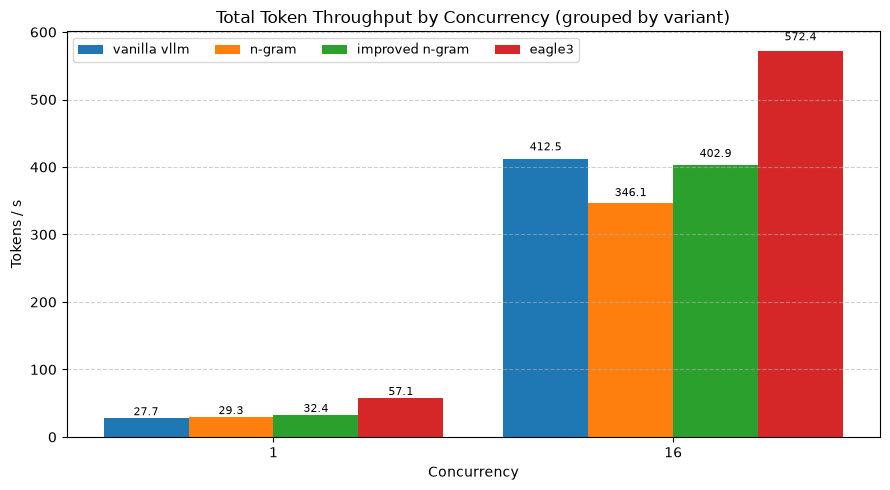

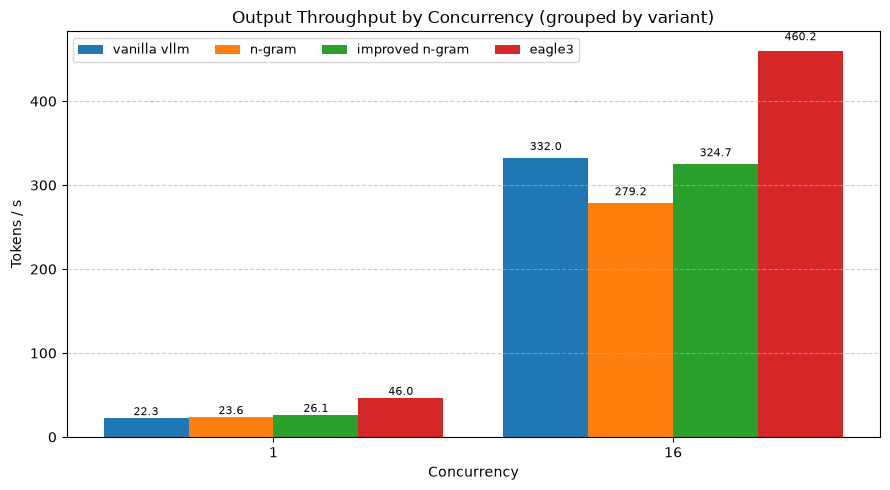

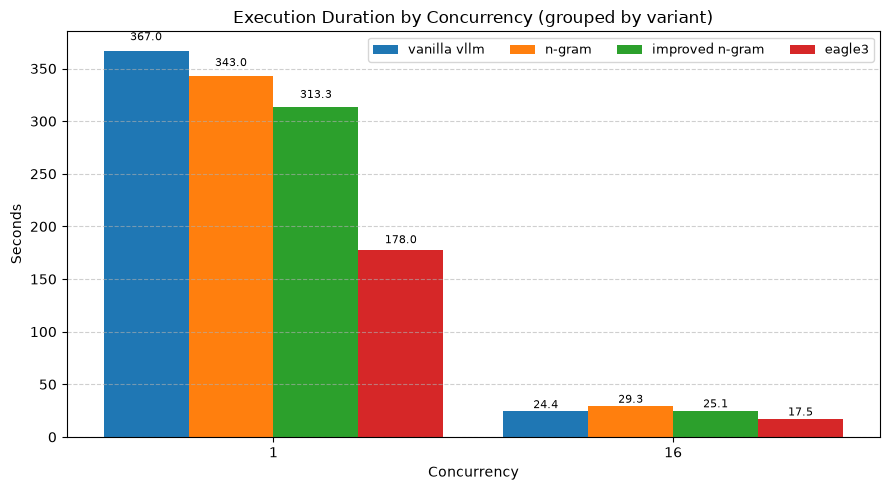

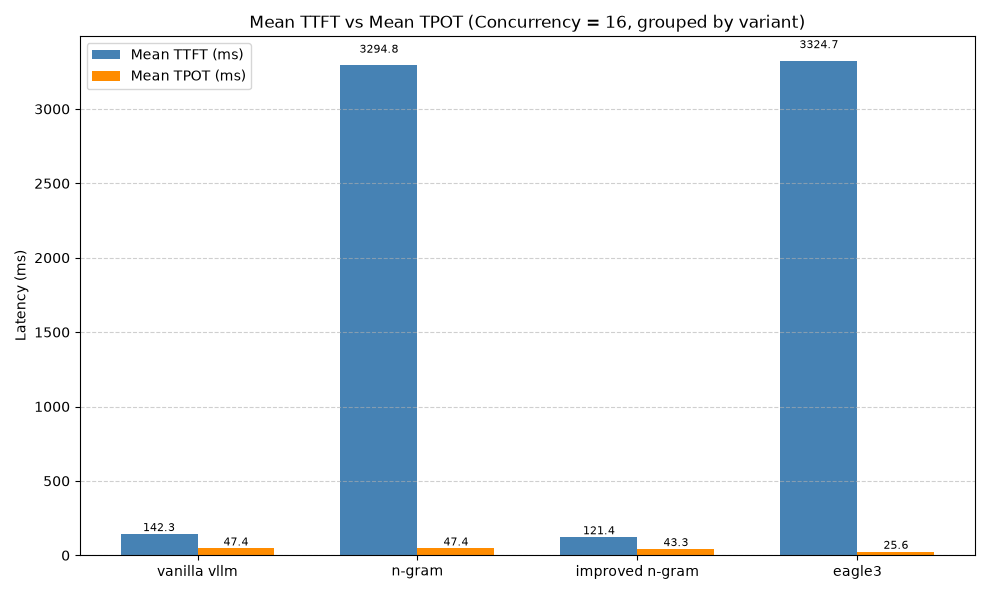

In [34]:
import json
import numpy as np
import matplotlib.pyplot as plt

# ----- Load: 변형별 파일에서 (재실행 대비 마지막 2줄만) -----
variant_slugs  = ['vanilla', 'ngram', 'ngram_improved', 'eagle3']
variant_labels = ['vanilla vllm', 'n-gram', 'improved n-gram', 'eagle3']
# eagle3 가 Blackwell 에서 안 뜨면 위 두 리스트에서 마지막 항목을 빼고 돌린다.

records = {}
for v_idx, slug in enumerate(variant_slugs):
    rows = [json.loads(l) for l in open(RESULT_DIR / f"{slug}.json") if l.strip()]
    for r in rows[-2:]:
        records[(v_idx, r["max_concurrency"])] = r

concs = sorted({k[1] for k in records})
if len(concs) != 2:
    raise ValueError(f"concurrency 2개를 기대했는데 {concs}")
c1, c2 = concs

missing = [(v, c) for v in range(len(variant_slugs)) for c in concs if (v, c) not in records]
if missing:
    raise ValueError(f"누락된 (variant_idx, concurrency): {missing}")

def metric_by_concurrency(key, scale=1.0):
    """Return arrays shaped (num_concurrencies=2, num_variants)."""
    vals_c1 = [records[(i, c1)][key] / scale for i in range(len(variant_labels))]
    vals_c2 = [records[(i, c2)][key] / scale for i in range(len(variant_labels))]
    return np.array([vals_c1, vals_c2])  # shape (2, V)

# ----- Extract metrics -----
total_tput = metric_by_concurrency("total_token_throughput")        # (2, V)
output_tput = metric_by_concurrency("output_throughput")            # (2, V)
durations   = metric_by_concurrency("duration")                     # (2, V)
mean_ttft   = metric_by_concurrency("mean_ttft_ms")                 # (2, V)
mean_tpot   = metric_by_concurrency("mean_tpot_ms")                 # (2, V)

# ----- Plot helper: x-axis = concurrencies, bars grouped by variant -----
def grouped_bars_by_variant(ax, values, title, ylabel, variants, concurrencies):
    """
    values: shape (num_concurrencies, num_variants)
    x-axis: concurrencies
    inside each concurrency bucket: one bar per variant
    """
    num_conc, num_vars = values.shape
    assert num_conc == 2, "This helper expects exactly 2 concurrencies."
    x = np.arange(num_conc)  # [0,1] -> [c1,c2]
    group_width = 0.85
    bar_width = group_width / num_vars
    # center the bars around each x
    offsets = (np.arange(num_vars) - (num_vars - 1) / 2.0) * bar_width

    for v_idx in range(num_vars):
        ax.bar(x + offsets[v_idx], values[:, v_idx], width=bar_width, label=variants[v_idx])

        # value labels
        for xi, val in zip(x + offsets[v_idx], values[:, v_idx]):
            ax.text(xi, val * 1.02, f"{val:.1f}", ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels([str(c) for c in concurrencies])
    ax.set_xlabel("Concurrency")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.legend(ncols=min(len(variants), 4), fontsize=9)

# =====================================================
# Plot 1: Total Token Throughput (tokens/s)
# =====================================================
fig, ax = plt.subplots(figsize=(9, 5))
grouped_bars_by_variant(
    ax,
    total_tput,
    title="Total Token Throughput by Concurrency (grouped by variant)",
    ylabel="Tokens / s",
    variants=variant_labels,
    concurrencies=[c1, c2],
)
plt.tight_layout()
plt.show()

# =====================================================
# Plot 2: Output Throughput (tokens/s)
# =====================================================
fig, ax = plt.subplots(figsize=(9, 5))
grouped_bars_by_variant(
    ax,
    output_tput,
    title="Output Throughput by Concurrency (grouped by variant)",
    ylabel="Tokens / s",
    variants=variant_labels,
    concurrencies=[c1, c2],
)
plt.tight_layout()
plt.show()

# =====================================================
# Plot 3: Duration (s)
# =====================================================
fig, ax = plt.subplots(figsize=(9, 5))
grouped_bars_by_variant(
    ax,
    durations,
    title="Execution Duration by Concurrency (grouped by variant)",
    ylabel="Seconds",
    variants=variant_labels,
    concurrencies=[c1, c2],
)
plt.tight_layout()
plt.show()

# =====================================================
# Plot 4: Latency (Mean TTFT vs Mean TPOT) — concurrency = 16
# =====================================================
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(variant_labels))
bar_width = 0.35

# Use index [1, :] for concurrency = 16
ttft_vals = mean_ttft[1, :]
tpot_vals = mean_tpot[1, :]

plt.bar(x - bar_width/2, ttft_vals, width=bar_width, label='Mean TTFT (ms)', color='steelblue')
plt.bar(x + bar_width/2, tpot_vals, width=bar_width, label='Mean TPOT (ms)', color='darkorange')

# Add numeric labels
for pos, val in zip(x - bar_width/2, ttft_vals):
    plt.text(pos, val * 1.02, f"{val:.1f}", ha='center', va='bottom', fontsize=8)
for pos, val in zip(x + bar_width/2, tpot_vals):
    plt.text(pos, val * 1.02, f"{val:.1f}", ha='center', va='bottom', fontsize=8)

plt.xticks(x, variant_labels)
plt.ylabel("Latency (ms)")
plt.title("Mean TTFT vs Mean TPOT (Concurrency = 16, grouped by variant)")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
